# **Install packages**

In [10]:
!pip install faiss-cpu h5py numpy pandas matplotlib seaborn


# **Import libraries**

In [11]:
import faiss
import h5py
import numpy as np
import pandas as pd
import time
import os
import gc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

np.random.seed(42)
print("faiss version:", faiss.__version__)
print("numpy version:", np.__version__)


faiss version: 1.13.2
numpy version: 2.0.2


# **Download the Deep1M dataset (HDF5)**

In [14]:
import urllib.request
import os

url  = "http://ann-benchmarks.com/deep-image-96-angular.hdf5"
file = "deep-image-96-angular.hdf5"

# Remove the file if it exists and is empty or corrupted from a previous failed download
if os.path.exists(file) and os.path.getsize(file) == 0:
    print(f"Removing empty file: {file}")
    os.remove(file)

if not os.path.exists(file):
    print("Downloading Deep1M dataset ...")
    try:
        urllib.request.urlretrieve(url, file)
        print("Download complete with urllib.request.")
    except urllib.error.HTTPError as e:
        if e.code == 403:
            print(f"urllib.request.urlretrieve failed with 403 Forbidden. Trying wget with user-agent...")
            # Fallback to wget with a user-agent to bypass potential restrictions
            !wget --header="User-Agent: Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/100.0.4896.88 Safari/537.36" "{url}" -O "{file}"
            print("Download complete with wget.")
        else:
            print(f"Download failed with HTTPError: {e}. Please check the URL or try again later.")
    except Exception as e:
        print(f"An unexpected error occurred during download: {e}")
else:
    print("Dataset already downloaded.")

if os.path.exists(file):
    print("File size:", round(os.path.getsize(file) / 1e6, 1), "MB")
else:
    print(f"File {file} does not exist after download attempt.")

Removing empty file: deep-image-96-angular.hdf5
urllib.request.urlretrieve failed with 403 Forbidden. Trying wget with user-agent...
--2026-03-28 14:47:50--  http://ann-benchmarks.com/deep-image-96-angular.hdf5
Resolving ann-benchmarks.com (ann-benchmarks.com)... 172.67.134.227, 104.21.25.235, 2606:4700:3035::6815:19eb, ...
Connecting to ann-benchmarks.com (ann-benchmarks.com)|172.67.134.227|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3848008288 (3.6G)
Saving to: ‘deep-image-96-angular.hdf5’

deep-image-96-angul 100%[===================>]   3.58G  67.8MB/s    in 49s     

2026-03-28 14:48:38 (75.7 MB/s) - ‘deep-image-96-angular.hdf5’ saved [3848008288/3848008288]

Download complete with wget.
File size: 3848.0 MB


# **Load the dataset**

In [15]:
with h5py.File("deep-image-96-angular.hdf5", "r") as f:
    print("HDF5 keys:", list(f.keys()))
    print("train shape:", f["train"].shape)
    print("test  shape:", f["test"].shape)
    print("neighbors  :", f["neighbors"].shape)

    # Load first 1M base vectors (the file has ~9.9M rows)
    xb_full = f["train"][:1_000_000].astype("float32")

    # Load all 10K query vectors
    xq_all = f["test"][:].astype("float32")

print("\nBase vectors loaded:", xb_full.shape)
print("Query vectors loaded:", xq_all.shape)
print("Vector dimension:", xb_full.shape[1])


HDF5 keys: ['distances', 'neighbors', 'test', 'train']
train shape: (9990000, 96)
test  shape: (10000, 96)
neighbors  : (10000, 100)

Base vectors loaded: (1000000, 96)
Query vectors loaded: (10000, 96)
Vector dimension: 96


# **L2-normalize vectors (required for angular/cosine distance)**

In [16]:
# Deep1M uses angular (cosine) distance.
# On L2-normalised vectors, inner product == cosine similarity.
# So we normalise everything and use METRIC_INNER_PRODUCT throughout.

def l2_normalize(x):
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)
    return (x / norms).astype("float32")

xb_full = l2_normalize(xb_full)
xq_all  = l2_normalize(xq_all)

d = xb_full.shape[1]   # 96 dimensions
k = 10                 # top-k neighbours

# We use 500 queries for benchmarking
xq = xq_all[:500]

print("Dimension (d):", d)
print("Queries used :", xq.shape)


Dimension (d): 96
Queries used : (500, 96)


# **Create 100K and 1M subsets**

In [17]:
# 100K subset
xb_100k = xb_full[:100_000].copy()

# 1M subset (already full)
xb_1m = xb_full[:1_000_000].copy()

print("100K subset shape:", xb_100k.shape)
print("1M  subset shape :", xb_1m.shape)


100K subset shape: (100000, 96)
1M  subset shape : (1000000, 96)


# **Compute exact ground truth for 100K and 1M subsets**

In [18]:
# Ground truth for 100K
index_exact_100k = faiss.IndexFlatIP(d)
index_exact_100k.add(xb_100k)
_, gt_100k = index_exact_100k.search(xq, k)
print("Ground truth (100K):", gt_100k.shape)

# Ground truth for 1M
index_exact_1m = faiss.IndexFlatIP(d)
index_exact_1m.add(xb_1m)
_, gt_1m = index_exact_1m.search(xq, k)
print("Ground truth (1M)  :", gt_1m.shape)


Ground truth (100K): (500, 10)
Ground truth (1M)  : (500, 10)


# **Define recall@10 helper function**

In [19]:
def recall_at_k(retrieved, ground_truth, k=10):
    hits = 0
    for r, g in zip(retrieved, ground_truth):
        hits += len(set(r[:k]) & set(g[:k]))
    return hits / (len(retrieved) * k)


# **For 100K Vectors**

# **IndexFlatIP (Exact Search)**

In [20]:
index_flat_100k = faiss.IndexFlatIP(d)

start = time.time()
index_flat_100k.add(xb_100k)
end = time.time()

flat_100k_build_time = end - start
flat_100k_memory_mb  = (index_flat_100k.ntotal * d * 4) / 1e6

print("IndexFlatIP build time (100K):", flat_100k_build_time)
print("IndexFlatIP memory MB  (100K):", flat_100k_memory_mb)


IndexFlatIP build time (100K): 0.038834333419799805
IndexFlatIP memory MB  (100K): 38.4


# **IndexFlatIP Search-100k**

In [21]:
query_times_flat_100k = []
I_flat_100k = []

for q in xq:
    start = time.time()
    _, I = index_flat_100k.search(q.reshape(1, -1), k)
    end = time.time()
    query_times_flat_100k.append(end - start)
    I_flat_100k.append(I[0])

I_flat_100k = np.array(I_flat_100k)

flat_100k_avg_time = np.mean(query_times_flat_100k)
flat_100k_std_time = np.std(query_times_flat_100k)
flat_100k_recall   = recall_at_k(I_flat_100k, gt_100k, k)

print("FlatIP average query time (s):", flat_100k_avg_time)
print("FlatIP std query time     (s):", flat_100k_std_time)
print("FlatIP total search time  (s):", np.sum(query_times_flat_100k))
print("FlatIP Recall@10          :", flat_100k_recall)


FlatIP average query time (s): 0.006193453311920166
FlatIP std query time     (s): 0.0005523392084808073
FlatIP total search time  (s): 3.096726655960083
FlatIP Recall@10          : 1.0


##**IndexIVFFlat Build - 100K**

In [22]:
nlist = 256
quantizer_ivf_100k = faiss.IndexFlatIP(d)
index_ivf_100k = faiss.IndexIVFFlat(quantizer_ivf_100k, d, nlist, faiss.METRIC_INNER_PRODUCT)

start = time.time()
index_ivf_100k.train(xb_100k)
index_ivf_100k.add(xb_100k)
end = time.time()

ivf_100k_build_time = end - start
ivf_100k_memory_mb  = (index_ivf_100k.ntotal * d * 4) / 1e6

print("IVFFlat build time (100K):", ivf_100k_build_time)
print("IVFFlat memory MB  (100K):", ivf_100k_memory_mb)


IVFFlat build time (100K): 2.275247097015381
IVFFlat memory MB  (100K): 38.4


## **IndexIVFFlat Search — 100K**

In [23]:
index_ivf_100k.nprobe = 32

query_times_ivf_100k = []
I_ivf_100k = []

for q in xq:
    start = time.time()
    _, I = index_ivf_100k.search(q.reshape(1, -1), k)
    end = time.time()
    query_times_ivf_100k.append(end - start)
    I_ivf_100k.append(I[0])

I_ivf_100k = np.array(I_ivf_100k)

ivf_100k_avg_time = np.mean(query_times_ivf_100k)
ivf_100k_std_time = np.std(query_times_ivf_100k)
ivf_100k_recall   = recall_at_k(I_ivf_100k, gt_100k, k)

print("IVFFlat nprobe:", index_ivf_100k.nprobe)
print("IVFFlat average query time (s):", ivf_100k_avg_time)
print("IVFFlat std query time     (s):", ivf_100k_std_time)
print("IVFFlat total search time  (s):", np.sum(query_times_ivf_100k))
print("IVFFlat Recall@10          :", ivf_100k_recall)


IVFFlat nprobe: 32
IVFFlat average query time (s): 0.0007833013534545898
IVFFlat std query time     (s): 0.0001202726849007366
IVFFlat total search time  (s): 0.3916506767272949
IVFFlat Recall@10          : 0.9948


## **IndexIVFPQ Build — 100K**

In [24]:
# d=96, M=12 → subvector size = 96/12 = 8  (must divide evenly)
nlist_pq = 256
M        = 12
nbits    = 8

quantizer_pq_100k = faiss.IndexFlatIP(d)
index_pq_100k = faiss.IndexIVFPQ(quantizer_pq_100k, d, nlist_pq, M, nbits)
index_pq_100k.metric_type = faiss.METRIC_INNER_PRODUCT

start = time.time()
index_pq_100k.train(xb_100k)
index_pq_100k.add(xb_100k)
end = time.time()

pq_100k_build_time = end - start
pq_100k_memory_mb  = (index_pq_100k.sa_code_size() * index_pq_100k.ntotal) / 1e6

print("IVFPQ build time (100K):", pq_100k_build_time)
print("IVFPQ memory MB  (100K):", pq_100k_memory_mb)


IVFPQ build time (100K): 6.99203896522522
IVFPQ memory MB  (100K): 1.3


## **IndexIVFPQ search — 100K**

In [25]:
index_pq_100k.nprobe = 32

query_times_pq_100k = []
I_pq_100k = []

for q in xq:
    start = time.time()
    _, I = index_pq_100k.search(q.reshape(1, -1), k)
    end = time.time()
    query_times_pq_100k.append(end - start)
    I_pq_100k.append(I[0])

I_pq_100k = np.array(I_pq_100k)

pq_100k_avg_time = np.mean(query_times_pq_100k)
pq_100k_std_time = np.std(query_times_pq_100k)
pq_100k_recall   = recall_at_k(I_pq_100k, gt_100k, k)

print("IVFPQ nprobe:", index_pq_100k.nprobe)
print("IVFPQ average query time (s):", pq_100k_avg_time)
print("IVFPQ std query time     (s):", pq_100k_std_time)
print("IVFPQ total search time  (s):", np.sum(query_times_pq_100k))
print("IVFPQ Recall@10          :", pq_100k_recall)


IVFPQ nprobe: 32
IVFPQ average query time (s): 0.000342564582824707
IVFPQ std query time     (s): 0.0002455461317590991
IVFPQ total search time  (s): 0.17128229141235352
IVFPQ Recall@10          : 0.4228


## **IndexHNSW Build — 100K**

In [26]:
index_hnsw_100k = faiss.IndexHNSWFlat(d, 32, faiss.METRIC_INNER_PRODUCT)
index_hnsw_100k.hnsw.efConstruction = 200

start = time.time()
index_hnsw_100k.add(xb_100k)
end = time.time()

hnsw_100k_build_time = end - start
hnsw_100k_memory_mb  = (index_hnsw_100k.ntotal * d * 4) / 1e6

print("HNSW build time (100K):", hnsw_100k_build_time)
print("HNSW memory MB  (100K):", hnsw_100k_memory_mb)


HNSW build time (100K): 51.48135328292847
HNSW memory MB  (100K): 38.4


## **IndexHNSW Search — 100K**

In [27]:
index_hnsw_100k.hnsw.efSearch = 64

query_times_hnsw_100k = []
I_hnsw_100k = []

for q in xq:
    start = time.time()
    _, I = index_hnsw_100k.search(q.reshape(1, -1), k)
    end = time.time()
    query_times_hnsw_100k.append(end - start)
    I_hnsw_100k.append(I[0])

I_hnsw_100k = np.array(I_hnsw_100k)

hnsw_100k_avg_time = np.mean(query_times_hnsw_100k)
hnsw_100k_std_time = np.std(query_times_hnsw_100k)
hnsw_100k_recall   = recall_at_k(I_hnsw_100k, gt_100k, k)

print("HNSW efSearch:", index_hnsw_100k.hnsw.efSearch)
print("HNSW average query time (s):", hnsw_100k_avg_time)
print("HNSW std query time     (s):", hnsw_100k_std_time)
print("HNSW total search time  (s):", np.sum(query_times_hnsw_100k))
print("HNSW Recall@10          :", hnsw_100k_recall)


HNSW efSearch: 64
HNSW average query time (s): 0.0003273577690124512
HNSW std query time     (s): 9.209711573179482e-05
HNSW total search time  (s): 0.16367888450622559
HNSW Recall@10          : 0.992


##  **IndexLSH Build — 100K**

In [28]:
nbits_lsh = 256   # 2 x d is a common heuristic

index_lsh_100k = faiss.IndexLSH(d, nbits_lsh)

start = time.time()
index_lsh_100k.add(xb_100k)
end = time.time()

lsh_100k_build_time = end - start
lsh_100k_memory_mb  = (index_lsh_100k.sa_code_size() * index_lsh_100k.ntotal) / 1e6

print("LSH build time (100K):", lsh_100k_build_time)
print("LSH memory MB  (100K):", lsh_100k_memory_mb)


LSH build time (100K): 0.20827722549438477
LSH memory MB  (100K): 3.2


## **IndexLSH Search — 100K**

In [29]:
query_times_lsh_100k = []
I_lsh_100k = []

for q in xq:
    start = time.time()
    _, I = index_lsh_100k.search(q.reshape(1, -1), k)
    end = time.time()
    query_times_lsh_100k.append(end - start)
    I_lsh_100k.append(I[0])

I_lsh_100k = np.array(I_lsh_100k)

lsh_100k_avg_time = np.mean(query_times_lsh_100k)
lsh_100k_std_time = np.std(query_times_lsh_100k)
lsh_100k_recall   = recall_at_k(I_lsh_100k, gt_100k, k)

print("LSH average query time (s):", lsh_100k_avg_time)
print("LSH std query time     (s):", lsh_100k_std_time)
print("LSH total search time  (s):", np.sum(query_times_lsh_100k))
print("LSH Recall@10          :", lsh_100k_recall)


LSH average query time (s): 0.0011692733764648436
LSH std query time     (s): 0.0011956936212156946
LSH total search time  (s): 0.5846366882324219
LSH Recall@10          : 0.4352


## **Summary Table — 100K Results**

In [30]:
results_100k = {
    "Index"           : ["FlatIP", "IVFFlat", "IVFPQ", "HNSW", "LSH"],
    "Build Time (s)"  : [flat_100k_build_time, ivf_100k_build_time,
                          pq_100k_build_time, hnsw_100k_build_time,
                          lsh_100k_build_time],
    "Avg Latency (ms)": [flat_100k_avg_time*1000, ivf_100k_avg_time*1000,
                          pq_100k_avg_time*1000,  hnsw_100k_avg_time*1000,
                          lsh_100k_avg_time*1000],
    "Std Latency (ms)": [flat_100k_std_time*1000, ivf_100k_std_time*1000,
                          pq_100k_std_time*1000,  hnsw_100k_std_time*1000,
                          lsh_100k_std_time*1000],
    "Total Search (s)": [sum(query_times_flat_100k), sum(query_times_ivf_100k),
                          sum(query_times_pq_100k),  sum(query_times_hnsw_100k),
                          sum(query_times_lsh_100k)],
    "Recall@10"       : [flat_100k_recall, ivf_100k_recall,
                          pq_100k_recall,  hnsw_100k_recall,
                          lsh_100k_recall],
    "Memory (MB)"     : [flat_100k_memory_mb, ivf_100k_memory_mb,
                          pq_100k_memory_mb, hnsw_100k_memory_mb,
                          lsh_100k_memory_mb],
}

df_100k = pd.DataFrame(results_100k).set_index("Index").round(4)
print("\n=== Results — 100K Vectors ===")
print(df_100k.to_string())



=== Results — 100K Vectors ===
         Build Time (s)  Avg Latency (ms)  Std Latency (ms)  Total Search (s)  Recall@10  Memory (MB)
Index                                                                                                
FlatIP           0.0388            6.1935            0.5523            3.0967     1.0000         38.4
IVFFlat          2.2752            0.7833            0.1203            0.3917     0.9948         38.4
IVFPQ            6.9920            0.3426            0.2455            0.1713     0.4228          1.3
HNSW            51.4814            0.3274            0.0921            0.1637     0.9920         38.4
LSH              0.2083            1.1693            1.1957            0.5846     0.4352          3.2


# **For 1M Vectors**

# **IndexFlatIP  Build — 1M**

In [31]:
index_flat_1m = faiss.IndexFlatIP(d)

start = time.time()
index_flat_1m.add(xb_1m)
end = time.time()

flat_1m_build_time = end - start
flat_1m_memory_mb  = (index_flat_1m.ntotal * d * 4) / 1e6

print("IndexFlatIP build time (1M):", flat_1m_build_time)
print("IndexFlatIP memory MB  (1M):", flat_1m_memory_mb)


IndexFlatIP build time (1M): 0.4376373291015625
IndexFlatIP memory MB  (1M): 384.0


## **IndexFlatIP Search — 1M**

In [32]:
query_times_flat_1m = []
I_flat_1m = []

for q in xq:
    start = time.time()
    _, I = index_flat_1m.search(q.reshape(1, -1), k)
    end = time.time()
    query_times_flat_1m.append(end - start)
    I_flat_1m.append(I[0])

I_flat_1m = np.array(I_flat_1m)

flat_1m_avg_time = np.mean(query_times_flat_1m)
flat_1m_std_time = np.std(query_times_flat_1m)
flat_1m_recall   = recall_at_k(I_flat_1m, gt_1m, k)

print("FlatIP average query time (s):", flat_1m_avg_time)
print("FlatIP std query time     (s):", flat_1m_std_time)
print("FlatIP total search time  (s):", np.sum(query_times_flat_1m))
print("FlatIP Recall@10          :", flat_1m_recall)


FlatIP average query time (s): 0.062154587745666505
FlatIP std query time     (s): 0.006011551890506227
FlatIP total search time  (s): 31.077293872833252
FlatIP Recall@10          : 1.0


## **IndexIVFFlat Build — 1M**

In [33]:
nlist_1m = 1024
quantizer_ivf_1m = faiss.IndexFlatIP(d)
index_ivf_1m = faiss.IndexIVFFlat(quantizer_ivf_1m, d, nlist_1m, faiss.METRIC_INNER_PRODUCT)

start = time.time()
index_ivf_1m.train(xb_1m[:500_000])   # train on 500K sample
index_ivf_1m.add(xb_1m)
end = time.time()

ivf_1m_build_time = end - start
ivf_1m_memory_mb  = (index_ivf_1m.ntotal * d * 4) / 1e6

print("IVFFlat build time (1M):", ivf_1m_build_time)
print("IVFFlat memory MB  (1M):", ivf_1m_memory_mb)


IVFFlat build time (1M): 25.925144910812378
IVFFlat memory MB  (1M): 384.0


## **IndexIVFFlat Search — 1M**

In [34]:
index_ivf_1m.nprobe = 64

query_times_ivf_1m = []
I_ivf_1m = []

for q in xq:
    start = time.time()
    _, I = index_ivf_1m.search(q.reshape(1, -1), k)
    end = time.time()
    query_times_ivf_1m.append(end - start)
    I_ivf_1m.append(I[0])

I_ivf_1m = np.array(I_ivf_1m)

ivf_1m_avg_time = np.mean(query_times_ivf_1m)
ivf_1m_std_time = np.std(query_times_ivf_1m)
ivf_1m_recall   = recall_at_k(I_ivf_1m, gt_1m, k)

print("IVFFlat nprobe:", index_ivf_1m.nprobe)
print("IVFFlat average query time (s):", ivf_1m_avg_time)
print("IVFFlat std query time     (s):", ivf_1m_std_time)
print("IVFFlat total search time  (s):", np.sum(query_times_ivf_1m))
print("IVFFlat Recall@10          :", ivf_1m_recall)


IVFFlat nprobe: 64
IVFFlat average query time (s): 0.006262017250061035
IVFFlat std query time     (s): 0.0030723635183401363
IVFFlat total search time  (s): 3.1310086250305176
IVFFlat Recall@10          : 0.9958


## **IndexIVFPQ  Build — 1M**

In [35]:
quantizer_pq_1m = faiss.IndexFlatIP(d)
index_pq_1m = faiss.IndexIVFPQ(quantizer_pq_1m, d, 1024, 12, 8)
index_pq_1m.metric_type = faiss.METRIC_INNER_PRODUCT

start = time.time()
index_pq_1m.train(xb_1m[:500_000])
index_pq_1m.add(xb_1m)
end = time.time()

pq_1m_build_time = end - start
pq_1m_memory_mb  = (index_pq_1m.sa_code_size() * index_pq_1m.ntotal) / 1e6

print("IVFPQ build time (1M):", pq_1m_build_time)
print("IVFPQ memory MB  (1M):", pq_1m_memory_mb)


IVFPQ build time (1M): 49.533336877822876
IVFPQ memory MB  (1M): 14.0


## **IndexIVFPQ Search — 1M**

In [36]:
index_pq_1m.nprobe = 64

query_times_pq_1m = []
I_pq_1m = []

for q in xq:
    start = time.time()
    _, I = index_pq_1m.search(q.reshape(1, -1), k)
    end = time.time()
    query_times_pq_1m.append(end - start)
    I_pq_1m.append(I[0])

I_pq_1m = np.array(I_pq_1m)

pq_1m_avg_time = np.mean(query_times_pq_1m)
pq_1m_std_time = np.std(query_times_pq_1m)
pq_1m_recall   = recall_at_k(I_pq_1m, gt_1m, k)

print("IVFPQ nprobe:", index_pq_1m.nprobe)
print("IVFPQ average query time (s):", pq_1m_avg_time)
print("IVFPQ std query time     (s):", pq_1m_std_time)
print("IVFPQ total search time  (s):", np.sum(query_times_pq_1m))
print("IVFPQ Recall@10          :", pq_1m_recall)


IVFPQ nprobe: 64
IVFPQ average query time (s): 0.004927573680877685
IVFPQ std query time     (s): 0.002771368230590141
IVFPQ total search time  (s): 2.4637868404388428
IVFPQ Recall@10          : 0.298


# **IndexHNSW Build — 1M**

In [37]:
index_hnsw_1m = faiss.IndexHNSWFlat(d, 32, faiss.METRIC_INNER_PRODUCT)
index_hnsw_1m.hnsw.efConstruction = 200

start = time.time()
index_hnsw_1m.add(xb_1m)
end = time.time()

hnsw_1m_build_time = end - start
hnsw_1m_memory_mb  = (index_hnsw_1m.ntotal * d * 4) / 1e6

print("HNSW build time (1M):", hnsw_1m_build_time)
print("HNSW memory MB  (1M):", hnsw_1m_memory_mb)


HNSW build time (1M): 971.4501802921295
HNSW memory MB  (1M): 384.0


## **IndexHNSW Search — 1M**

In [38]:
index_hnsw_1m.hnsw.efSearch = 64

query_times_hnsw_1m = []
I_hnsw_1m = []

for q in xq:
    start = time.time()
    _, I = index_hnsw_1m.search(q.reshape(1, -1), k)
    end = time.time()
    query_times_hnsw_1m.append(end - start)
    I_hnsw_1m.append(I[0])

I_hnsw_1m = np.array(I_hnsw_1m)

hnsw_1m_avg_time = np.mean(query_times_hnsw_1m)
hnsw_1m_std_time = np.std(query_times_hnsw_1m)
hnsw_1m_recall   = recall_at_k(I_hnsw_1m, gt_1m, k)

print("HNSW efSearch:", index_hnsw_1m.hnsw.efSearch)
print("HNSW average query time (s):", hnsw_1m_avg_time)
print("HNSW std query time     (s):", hnsw_1m_std_time)
print("HNSW total search time  (s):", np.sum(query_times_hnsw_1m))
print("HNSW Recall@10          :", hnsw_1m_recall)


HNSW efSearch: 64
HNSW average query time (s): 0.00038389062881469726
HNSW std query time     (s): 7.966587281752753e-05
HNSW total search time  (s): 0.19194531440734863
HNSW Recall@10          : 0.9724


## **IndexLSH Build — 1M**

In [39]:
index_lsh_1m = faiss.IndexLSH(d, 256)

start = time.time()
index_lsh_1m.add(xb_1m)
end = time.time()

lsh_1m_build_time = end - start
lsh_1m_memory_mb  = (index_lsh_1m.sa_code_size() * index_lsh_1m.ntotal) / 1e6

print("LSH build time (1M):", lsh_1m_build_time)
print("LSH memory MB  (1M):", lsh_1m_memory_mb)


LSH build time (1M): 3.5568251609802246
LSH memory MB  (1M): 32.0


## **IndexLSH Search — 1M**

In [40]:
query_times_lsh_1m = []
I_lsh_1m = []

for q in xq:
    start = time.time()
    _, I = index_lsh_1m.search(q.reshape(1, -1), k)
    end = time.time()
    query_times_lsh_1m.append(end - start)
    I_lsh_1m.append(I[0])

I_lsh_1m = np.array(I_lsh_1m)

lsh_1m_avg_time = np.mean(query_times_lsh_1m)
lsh_1m_std_time = np.std(query_times_lsh_1m)
lsh_1m_recall   = recall_at_k(I_lsh_1m, gt_1m, k)

print("LSH average query time (s):", lsh_1m_avg_time)
print("LSH std query time     (s):", lsh_1m_std_time)
print("LSH total search time  (s):", np.sum(query_times_lsh_1m))
print("LSH Recall@10          :", lsh_1m_recall)


LSH average query time (s): 0.006123595714569092
LSH std query time     (s): 0.0020324427932474597
LSH total search time  (s): 3.061797857284546
LSH Recall@10          : 0.3392


## **Summary Table — 1M Results**

In [41]:
results_1m = {
    "Index"           : ["FlatIP", "IVFFlat", "IVFPQ", "HNSW", "LSH"],
    "Build Time (s)"  : [flat_1m_build_time, ivf_1m_build_time,
                          pq_1m_build_time, hnsw_1m_build_time,
                          lsh_1m_build_time],
    "Avg Latency (ms)": [flat_1m_avg_time*1000, ivf_1m_avg_time*1000,
                          pq_1m_avg_time*1000,  hnsw_1m_avg_time*1000,
                          lsh_1m_avg_time*1000],
    "Std Latency (ms)": [flat_1m_std_time*1000, ivf_1m_std_time*1000,
                          pq_1m_std_time*1000,  hnsw_1m_std_time*1000,
                          lsh_1m_std_time*1000],
    "Total Search (s)": [sum(query_times_flat_1m), sum(query_times_ivf_1m),
                          sum(query_times_pq_1m),  sum(query_times_hnsw_1m),
                          sum(query_times_lsh_1m)],
    "Recall@10"       : [flat_1m_recall, ivf_1m_recall,
                          pq_1m_recall,  hnsw_1m_recall,
                          lsh_1m_recall],
    "Memory (MB)"     : [flat_1m_memory_mb, ivf_1m_memory_mb,
                          pq_1m_memory_mb,  hnsw_1m_memory_mb,
                          lsh_1m_memory_mb],
}

df_1m = pd.DataFrame(results_1m).set_index("Index").round(4)
print("\n=== Results — 1M Vectors ===")
print(df_1m.to_string())



=== Results — 1M Vectors ===
         Build Time (s)  Avg Latency (ms)  Std Latency (ms)  Total Search (s)  Recall@10  Memory (MB)
Index                                                                                                
FlatIP           0.4376           62.1546            6.0116           31.0773     1.0000        384.0
IVFFlat         25.9251            6.2620            3.0724            3.1310     0.9958        384.0
IVFPQ           49.5333            4.9276            2.7714            2.4638     0.2980         14.0
HNSW           971.4502            0.3839            0.0797            0.1919     0.9724        384.0
LSH              3.5568            6.1236            2.0324            3.0618     0.3392         32.0


# **Hyperparameter Tuning**

##  **nprobe Sweep for IVFFlat (100K)**

In [42]:
nprobe_values = [1, 2, 4, 8, 16, 32, 64, 128, 256]
nprobe_latency = []
nprobe_recall  = []

for np_val in nprobe_values:
    index_ivf_100k.nprobe = np_val
    times, results = [], []

    for q in xq:
        start = time.time()
        _, I = index_ivf_100k.search(q.reshape(1, -1), k)
        end = time.time()
        times.append(end - start)
        results.append(I[0])

    avg_t  = np.mean(times)
    rec    = recall_at_k(np.array(results), gt_100k, k)
    nprobe_latency.append(avg_t)
    nprobe_recall.append(rec)
    print("nprobe:", np_val, "| avg time (s):", round(avg_t, 5), "| recall@10:", round(rec, 4))


nprobe: 1 | avg time (s): 5e-05 | recall@10: 0.4932
nprobe: 2 | avg time (s): 5e-05 | recall@10: 0.675
nprobe: 4 | avg time (s): 9e-05 | recall@10: 0.8334
nprobe: 8 | avg time (s): 0.00019 | recall@10: 0.931
nprobe: 16 | avg time (s): 0.00033 | recall@10: 0.9756
nprobe: 32 | avg time (s): 0.00065 | recall@10: 0.9948
nprobe: 64 | avg time (s): 0.00157 | recall@10: 0.9988
nprobe: 128 | avg time (s): 0.00222 | recall@10: 1.0
nprobe: 256 | avg time (s): 0.0042 | recall@10: 1.0


## **efSearch Sweep for HNSW (100K)**

In [43]:
ef_values  = [4, 8, 16, 32, 64, 128, 256, 512]
ef_latency = []
ef_recall  = []

for ef in ef_values:
    index_hnsw_100k.hnsw.efSearch = ef
    times, results = [], []

    for q in xq:
        start = time.time()
        _, I = index_hnsw_100k.search(q.reshape(1, -1), k)
        end = time.time()
        times.append(end - start)
        results.append(I[0])

    avg_t = np.mean(times)
    rec   = recall_at_k(np.array(results), gt_100k, k)
    ef_latency.append(avg_t)
    ef_recall.append(rec)
    print("efSearch:", ef, "| avg time (s):", round(avg_t, 5), "| recall@10:", round(rec, 4))


efSearch: 4 | avg time (s): 0.0001 | recall@10: 0.6766
efSearch: 8 | avg time (s): 8e-05 | recall@10: 0.8116
efSearch: 16 | avg time (s): 0.00011 | recall@10: 0.9158
efSearch: 32 | avg time (s): 0.00018 | recall@10: 0.973
efSearch: 64 | avg time (s): 0.00026 | recall@10: 0.992
efSearch: 128 | avg time (s): 0.00041 | recall@10: 0.9988
efSearch: 256 | avg time (s): 0.00073 | recall@10: 0.9996
efSearch: 512 | avg time (s): 0.0013 | recall@10: 0.9998


# **Visualizations**

## **Plot 1 — Index Build Time Comparison**

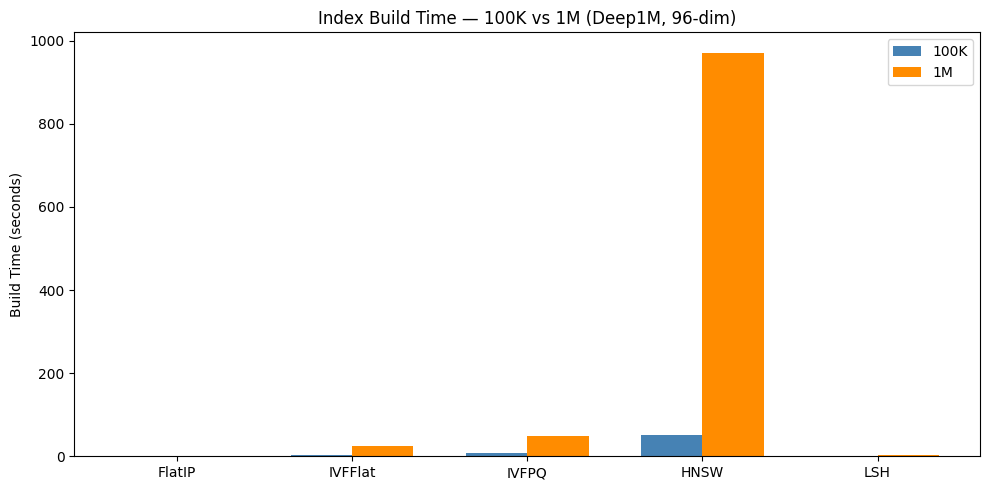

Saved: plot1_build_time.png


In [63]:
indexes  = ["FlatIP", "IVFFlat", "IVFPQ", "HNSW", "LSH"]
build_100k = [flat_100k_build_time, ivf_100k_build_time, pq_100k_build_time,
              hnsw_100k_build_time, lsh_100k_build_time]
build_1m   = [flat_1m_build_time, ivf_1m_build_time, pq_1m_build_time,
              hnsw_1m_build_time, lsh_1m_build_time]

x = np.arange(len(indexes))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, build_100k, width, label="100K", color="steelblue")
plt.bar(x + width/2, build_1m,   width, label="1M",   color="darkorange")
plt.xticks(x, indexes)
plt.ylabel("Build Time (seconds)")
plt.title("Index Build Time — 100K vs 1M (Deep1M, 96-dim)")
plt.legend()
plt.tight_layout()
plt.savefig("plot1_build_time.png", dpi=150)
plt.show()
print("Saved: plot1_build_time.png")


## **Plot 2 — Average Query Latency (error bars)**

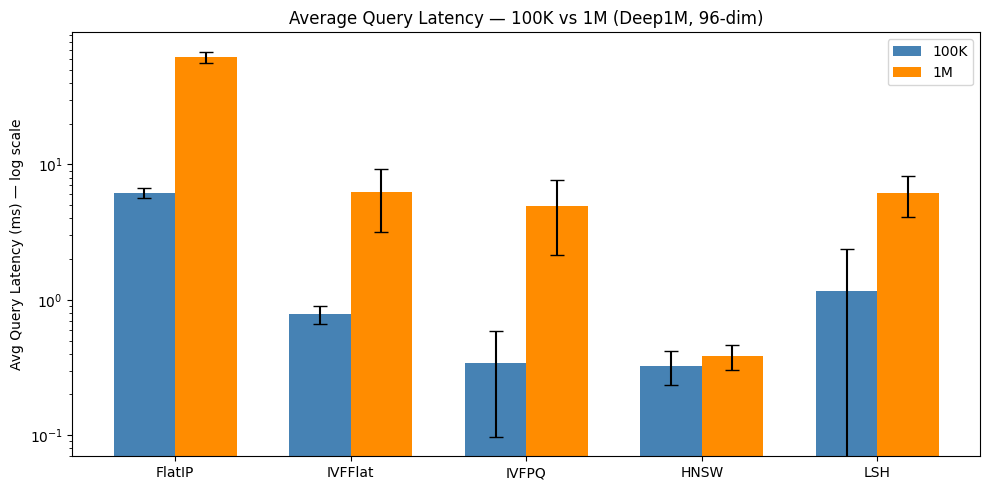

Saved: plot2_query_latency.png


In [61]:
lat_100k = [flat_100k_avg_time*1000, ivf_100k_avg_time*1000, pq_100k_avg_time*1000,
            hnsw_100k_avg_time*1000, lsh_100k_avg_time*1000]
std_100k = [flat_100k_std_time*1000, ivf_100k_std_time*1000, pq_100k_std_time*1000,
            hnsw_100k_std_time*1000, lsh_100k_std_time*1000]

lat_1m   = [flat_1m_avg_time*1000, ivf_1m_avg_time*1000, pq_1m_avg_time*1000,
            hnsw_1m_avg_time*1000, lsh_1m_avg_time*1000]
std_1m   = [flat_1m_std_time*1000, ivf_1m_std_time*1000, pq_1m_std_time*1000,
            hnsw_1m_std_time*1000, lsh_1m_std_time*1000]

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, lat_100k, width, yerr=std_100k, capsize=5, label="100K", color="steelblue")
plt.bar(x + width/2, lat_1m,   width, yerr=std_1m,   capsize=5, label="1M",   color="darkorange")
plt.xticks(x, indexes)
plt.yscale("log")
plt.ylabel("Avg Query Latency (ms) — log scale")
plt.title("Average Query Latency — 100K vs 1M (Deep1M, 96-dim)")
plt.legend()
plt.tight_layout()
plt.savefig("plot2_query_latency.png", dpi=150)
plt.show()
print("Saved: plot2_query_latency.png")


## **Plot 3 — Recall@10 Comparison**

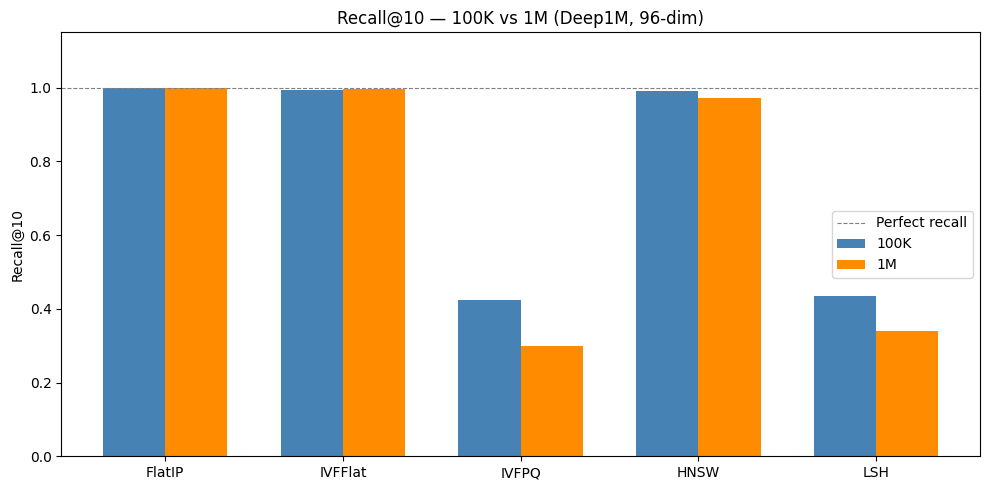

Saved: plot3_recall.png


In [60]:
rec_100k = [flat_100k_recall, ivf_100k_recall, pq_100k_recall,
            hnsw_100k_recall, lsh_100k_recall]
rec_1m   = [flat_1m_recall,   ivf_1m_recall,   pq_1m_recall,
            hnsw_1m_recall,   lsh_1m_recall]

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, rec_100k, width, label="100K", color="steelblue")
plt.bar(x + width/2, rec_1m,   width, label="1M",   color="darkorange")
plt.axhline(1.0, linestyle="--", color="gray", linewidth=0.8, label="Perfect recall")
plt.xticks(x, indexes)
plt.ylim(0, 1.15)
plt.ylabel("Recall@10")
plt.title("Recall@10 — 100K vs 1M (Deep1M, 96-dim)")
plt.legend()
plt.tight_layout()
plt.savefig("plot3_recall.png", dpi=150)
plt.show()
print("Saved: plot3_recall.png")


## **Plot 4 — Memory Usage Comparison**

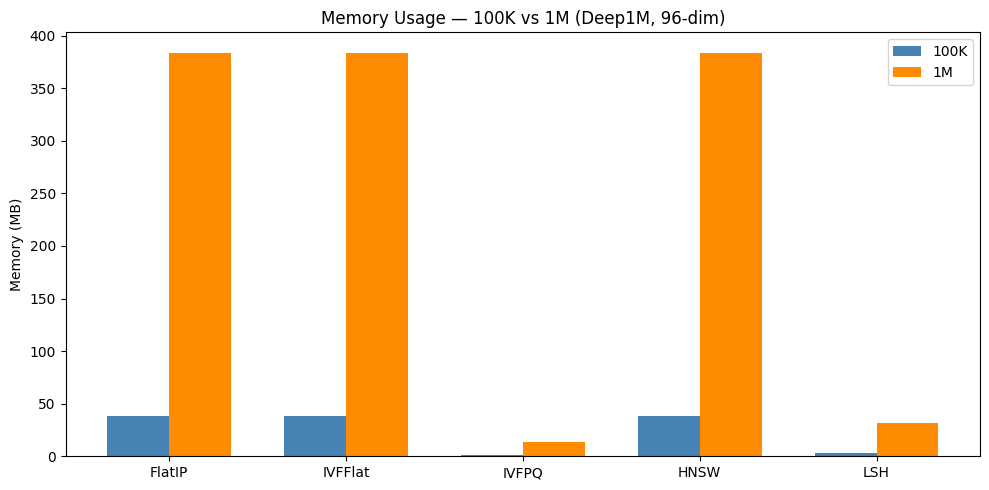

Saved: plot4_memory.png


In [59]:
mem_100k = [flat_100k_memory_mb, ivf_100k_memory_mb, pq_100k_memory_mb,
            hnsw_100k_memory_mb, lsh_100k_memory_mb]
mem_1m   = [flat_1m_memory_mb,   ivf_1m_memory_mb,   pq_1m_memory_mb,
            hnsw_1m_memory_mb,   lsh_1m_memory_mb]

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, mem_100k, width, label="100K", color="steelblue")
plt.bar(x + width/2, mem_1m,   width, label="1M",   color="darkorange")
plt.xticks(x, indexes)
plt.ylabel("Memory (MB)")
plt.title("Memory Usage — 100K vs 1M (Deep1M, 96-dim)")
plt.legend()
plt.tight_layout()
plt.savefig("plot4_memory.png", dpi=150)
plt.show()
print("Saved: plot4_memory.png")


## **Plot 5 — Recall vs Latency Scatter (Trade-off)**

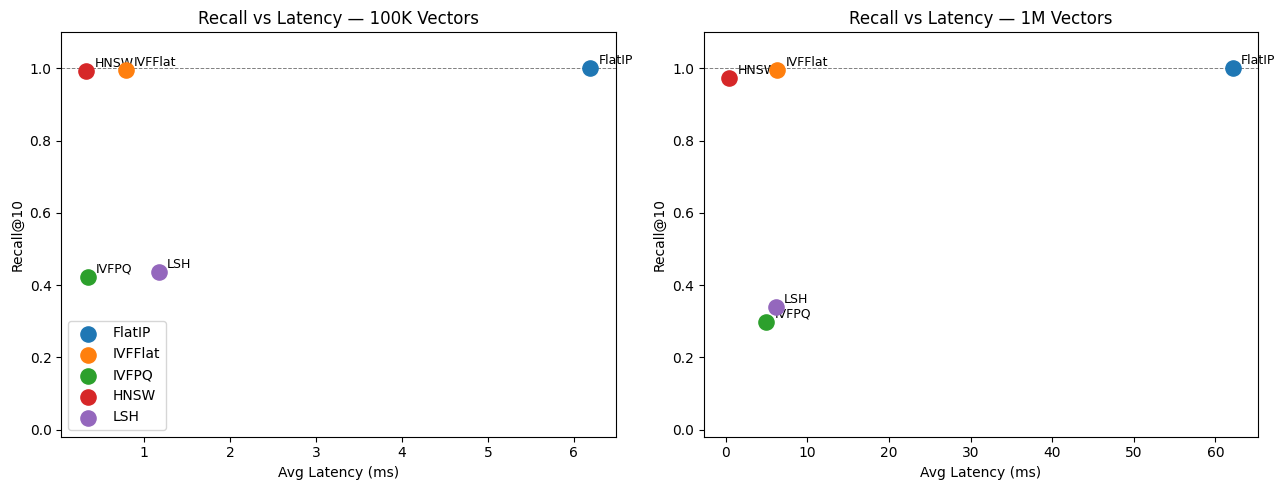

Saved: plot5_recall_vs_latency.png


In [65]:
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, name in enumerate(indexes):
    axes[0].scatter(lat_100k[i], rec_100k[i], color=colors[i], s=120, label=name, zorder=5)
    axes[0].annotate(name, (lat_100k[i], rec_100k[i]), textcoords="offset points",
                     xytext=(6, 3), fontsize=9)

    axes[1].scatter(lat_1m[i], rec_1m[i], color=colors[i], s=120, label=name, zorder=5)
    axes[1].annotate(name, (lat_1m[i], rec_1m[i]), textcoords="offset points",
                     xytext=(6, 3), fontsize=9)

for ax, title in zip(axes, ["100K Vectors", "1M Vectors"]):
    ax.set_xlabel("Avg Latency (ms)")
    ax.set_ylabel("Recall@10")
    ax.set_ylim(-0.02, 1.1)
    ax.axhline(1.0, linestyle="--", color="gray", linewidth=0.7)
    ax.set_title("Recall vs Latency — " + title)

axes[0].legend()
plt.tight_layout()
plt.savefig("plot5_recall_vs_latency.png", dpi=150)
plt.show()
print("Saved: plot5_recall_vs_latency.png")


## **Plot 6 — Scalability: 100K → 1M**

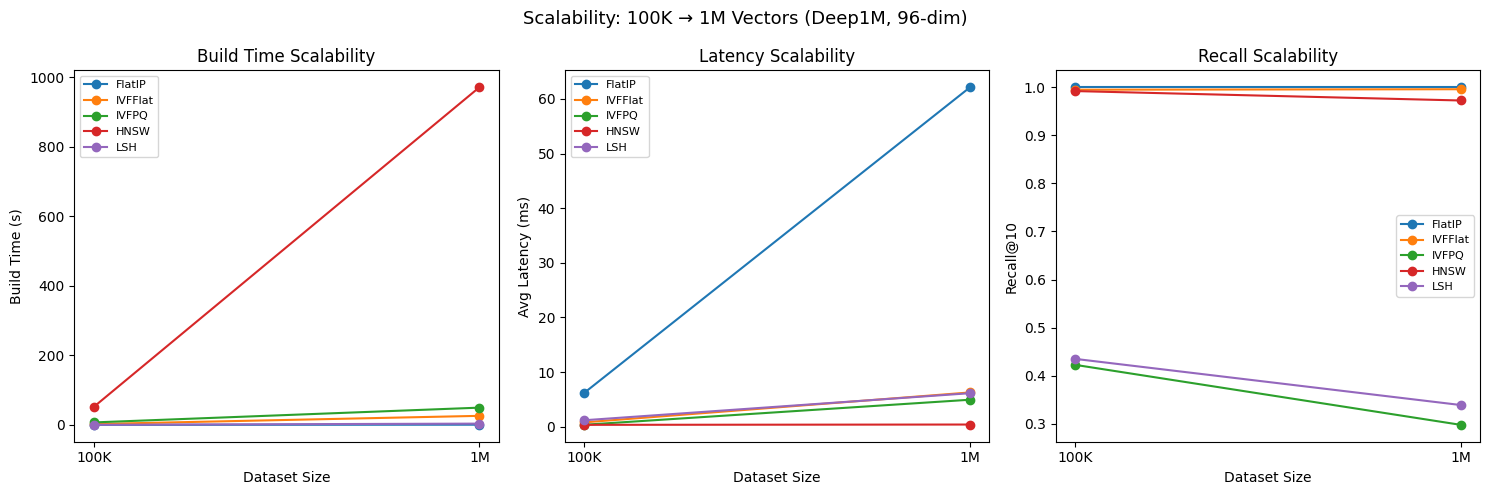

Saved: plot6_scalability.png


In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sizes = ["100K", "1M"]

for i, name in enumerate(indexes):
    axes[0].plot(sizes, [build_100k[i], build_1m[i]], marker="o", label=name, color=colors[i])
    axes[1].plot(sizes, [lat_100k[i],   lat_1m[i]],   marker="o", label=name, color=colors[i])
    axes[2].plot(sizes, [rec_100k[i],   rec_1m[i]],   marker="o", label=name, color=colors[i])

axes[0].set_ylabel("Build Time (s)")
axes[0].set_title("Build Time Scalability")
axes[1].set_ylabel("Avg Latency (ms)")
axes[1].set_title("Latency Scalability")
axes[2].set_ylabel("Recall@10")
axes[2].set_title("Recall Scalability")

for ax in axes:
    ax.set_xlabel("Dataset Size")
    ax.legend(fontsize=8)

plt.suptitle("Scalability: 100K → 1M Vectors (Deep1M, 96-dim)", fontsize=13)
plt.tight_layout()
plt.savefig("plot6_scalability.png", dpi=150)
plt.show()
print("Saved: plot6_scalability.png")


## **Plot 7 — Hyperparameter Tuning Curves (nprobe and efSearch)**

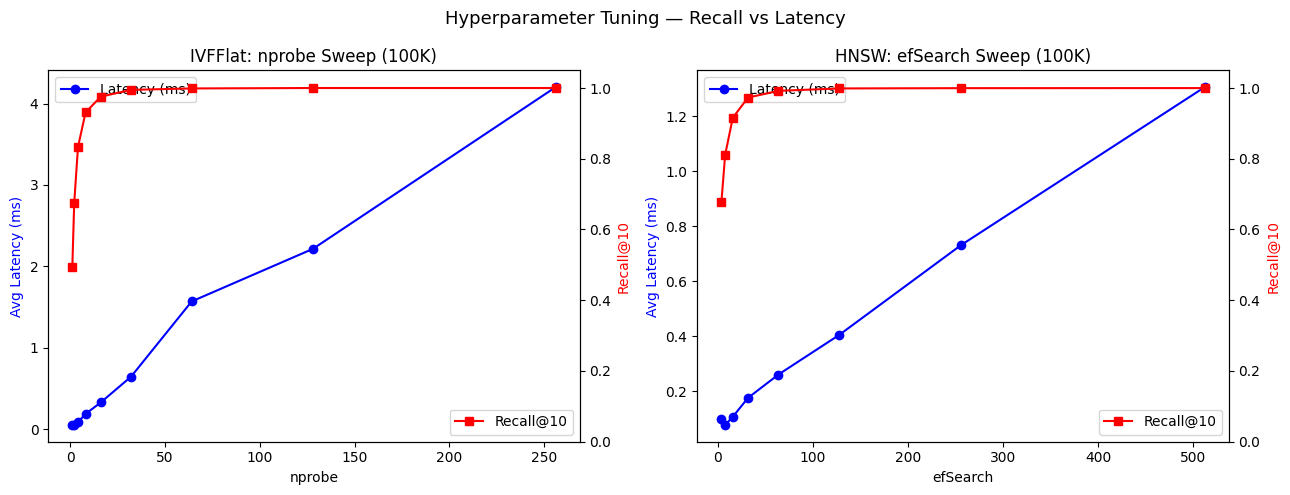

Saved: plot7_hyperparameter.png


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# nprobe sweep
ax1 = axes[0]
ax1b = ax1.twinx()
ax1.plot(nprobe_values, [t*1000 for t in nprobe_latency], "b-o", label="Latency (ms)")
ax1b.plot(nprobe_values, nprobe_recall, "r-s", label="Recall@10")
ax1.set_xlabel("nprobe")
ax1.set_ylabel("Avg Latency (ms)", color="blue")
ax1b.set_ylabel("Recall@10", color="red")
ax1b.set_ylim(0, 1.05)
ax1.set_title("IVFFlat: nprobe Sweep (100K)")
ax1.legend(loc="upper left")
ax1b.legend(loc="lower right")

# efSearch sweep
ax2 = axes[1]
ax2b = ax2.twinx()
ax2.plot(ef_values, [t*1000 for t in ef_latency], "b-o", label="Latency (ms)")
ax2b.plot(ef_values, ef_recall, "r-s", label="Recall@10")
ax2.set_xlabel("efSearch")
ax2.set_ylabel("Avg Latency (ms)", color="blue")
ax2b.set_ylabel("Recall@10", color="red")
ax2b.set_ylim(0, 1.05)
ax2.set_title("HNSW: efSearch Sweep (100K)")
ax2.legend(loc="upper left")
ax2b.legend(loc="lower right")

plt.suptitle("Hyperparameter Tuning — Recall vs Latency", fontsize=13)
plt.tight_layout()
plt.savefig("plot7_hyperparameter.png", dpi=150)
plt.show()
print("Saved: plot7_hyperparameter.png")


## **Plot 8 — Heatmap: Relative Performance Overview**

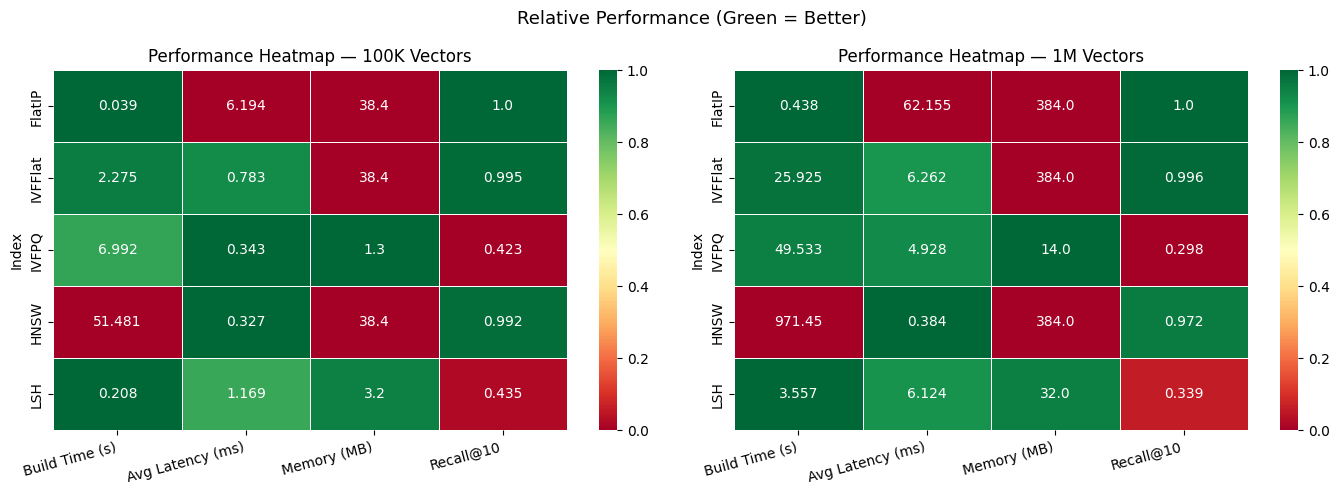

Saved: plot8_heatmap.png


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in zip(axes, [df_100k, df_1m], ["100K", "1M"]):
    cols  = ["Build Time (s)", "Avg Latency (ms)", "Memory (MB)", "Recall@10"]
    heat  = df[cols].copy().astype(float)

    # Lower build time / latency / memory = better → invert to 1 = best
    for c in ["Build Time (s)", "Avg Latency (ms)", "Memory (MB)"]:
        mn, mx = heat[c].min(), heat[c].max()
        heat[c] = 1 - (heat[c] - mn) / (mx - mn + 1e-9)

    # Higher recall = better
    mn, mx = heat["Recall@10"].min(), heat["Recall@10"].max()
    heat["Recall@10"] = (heat["Recall@10"] - mn) / (mx - mn + 1e-9)

    sns.heatmap(heat, ax=ax, annot=df[cols].round(3), fmt="",
                cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5)
    ax.set_title("Performance Heatmap — " + title + " Vectors")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")

plt.suptitle("Relative Performance (Green = Better)", fontsize=13)
plt.tight_layout()
plt.savefig("plot8_heatmap.png", dpi=150)
plt.show()
print("Saved: plot8_heatmap.png")


# **Final Summary**

In [52]:
print("==========================================================")
print("  FINAL SUMMARY — FAISS on Deep1M (96-dim, Inner Product)")
print("==========================================================")

for label, df in [("100K", df_100k), ("1M", df_1m)]:
    print("\n--- Dataset:", label, "vectors ---")
    print("Fastest query  :", df["Avg Latency (ms)"].idxmin(),
          "(", round(df["Avg Latency (ms)"].min(), 4), "ms )")
    print("Best recall    :", df["Recall@10"].idxmax(),
          "( recall@10 =", round(df["Recall@10"].max(), 4), ")")
    print("Least memory   :", df["Memory (MB)"].idxmin(),
          "(", round(df["Memory (MB)"].min(), 2), "MB )")
    print("Fastest build  :", df["Build Time (s)"].idxmin(),
          "(", round(df["Build Time (s)"].min(), 4), "s )")

print("\n")
print("Saved plots:")
for p in ["plot1_build_time.png", "plot2_query_latency.png", "plot3_recall.png",
          "plot4_memory.png", "plot5_recall_vs_latency.png",
          "plot6_scalability.png", "plot7_hyperparameter.png", "plot8_heatmap.png"]:
    status = "OK" if os.path.exists(p) else "MISSING"
    print(" ", status, "—", p)


  FINAL SUMMARY — FAISS on Deep1M (96-dim, Inner Product)

--- Dataset: 100K vectors ---
Fastest query  : HNSW ( 0.3274 ms )
Best recall    : FlatIP ( recall@10 = 1.0 )
Least memory   : IVFPQ ( 1.3 MB )
Fastest build  : FlatIP ( 0.0388 s )

--- Dataset: 1M vectors ---
Fastest query  : HNSW ( 0.3839 ms )
Best recall    : FlatIP ( recall@10 = 1.0 )
Least memory   : IVFPQ ( 14.0 MB )
Fastest build  : FlatIP ( 0.4376 s )


Saved plots:
  OK — plot1_build_time.png
  OK — plot2_query_latency.png
  OK — plot3_recall.png
  OK — plot4_memory.png
  OK — plot5_recall_vs_latency.png
  OK — plot6_scalability.png
  OK — plot7_hyperparameter.png
  OK — plot8_heatmap.png
